# Дизайн A/B-тестов
> Осинкин Александр 10И3

## План

- Базовая постановка A/B-теста
- Тесты, ошибки I/II рода, мощность и MDE
- Валидация критериев через синтетические A/A и A/B
- Непараметрические критерии
- Ratio-метрики: дельта-метод, линеаризация, бакетизация, bootstrap
- Доверительные интервалы и uplift
- Персентильные доверительные интервалы
- Аутлайеры
- CUPED
- Стратификация и постстратификация
- Множественное тестирование
- Байесовский A/B-тест
- Итоговый чеклист проведения эксперимента


## 1. Базовая постановка A/B-теста

A/B-тест -- это контролируемый эксперимент, где пользователей делят на две группы:

- **control** -- текущая версия продукта;
- **test** -- версия с изменением.

Дальше выбирается метрика и формулируются гипотезы:

- $H_0$: эффекта нет, изменение не повлияло на метрику;
- $H_1$: эффект есть.

Нужно понимать:

- какую гипотезу проверяет критерий;
- валиден ли критерий на наших данных;
- какую ошибку первого рода он дает;
- какая у него мощность;
- какой минимальный эффект он способен найти;
- как устроена метрика: обычная value-метрика или ratio-метрика;
- сколько гипотез мы проверяем одновременно.

Иначе можно получить хороший `p-value`, но принять ложные выводы.


## 2. Z-test, T-test и сравнение средних

Для сравнения средних используется статистика вида:

$$
T = \frac{\bar X_T - \bar X_C}{SE(\bar X_T - \bar X_C)}
$$

где $SE$ -- стандартная ошибка разницы средних.

Разница между Z-test и T-test:

1. **Z-test** использует стандартное нормальное распределение, глобально только асимптотическая версия.
2. **T-test** использует распределение Стьюдента и выборочную дисперсию.

> Крч просто ттест используем и все.


## 3. Ошибки первого и второго рода

**Ошибка первого рода**:

$$
\alpha = P(\text{отвергли } H_0 \mid H_0 \text{ верна})
$$

То есть эффекта нет, но мы сказали, что он есть.

**Ошибка второго рода**:

$$
\beta = P(\text{не отвергли } H_0 \mid H_1 \text{ верна})
$$

То есть эффект есть, но мы его не нашли.

**Мощность**:

$$
power = 1 - \beta
$$

Обычно берут $\alpha=5\%$ и $\beta=20\%$, то есть мощность $80\%$. Уровни ошибок выбираются по цене ошибки.

Примеры:

- диагностика болезни: страшно не найти болезнь, если она есть, поэтому важна ошибка второго рода;
- проверка лекарства: страшно объявить лекарство работающим, если оно плацебо, поэтому важна ошибка первого рода;
- продуктовый эксперимент: нужно понять, что дороже -- ложный запуск фичи или пропуск реального эффекта.

## 4. MDE и расчет размера выборки

Начнем с power (все для z-test, для примера)
$$
power(\delta) = \Phi(z_{\alpha / 2} - \frac{\delta}{\sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}}}) + 1 - \Phi_Z(z_{1 - \alpha / 2} - \frac{\delta}{\sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}}})
$$

**MDE** -- minimum detectable effect, минимальный эффект, который эксперимент способен обнаружить с заданной мощностью.

> Крч, в итоге, нет четкой формулы для двустороннего теста, просто потому, что здесь $\Phi$ не возвести в -1 степень, из за того, что их тута 2. Поэтому, можно сказать, что тест односторонний (с другой стороны вероятность будет оч маленькая), допустим $\delta > 0$, тогда

$$
1 - \beta = 1 - \Phi_Z(z_{1 - \alpha / 2} - \frac{\delta}{\sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}}})\\
\beta = \Phi_Z(z_{1 - \alpha / 2} - \frac{\delta}{\sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}}})\\
z_{\beta} = z_{1 - \alpha / 2} - \frac{\delta}{\sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}}}\\
MDE = \sqrt{\frac{\sigma^2_1}{n_1} + \frac{\sigma^2_2}{n_2}} (z_{1 - \alpha / 2} - z_{\beta})
$$

(из этого и n выводится)

Из формулы видно:

- чем больше $n$, тем меньше MDE;
- чем выше дисперсия, тем больше MDE;
- чем строже $\alpha$, тем больше MDE;
- чем выше требуемая мощность, тем больше MDE;




> Мини-итог: если ожидаемый продуктовый эффект меньше MDE, эксперимент может закончиться серым результатом не потому, что эффекта нет, а потому что мощность слишком маленькая. Поэтому MDE и размер выборки считаются до запуска.


## 5. Синтетические A/B-тесты и мощность критерия

A/A проверяет валидность: ошибается ли критерий на нужном уровне, когда эффекта нет.

A/B проверяет мощность: как часто критерий находит эффект, когда мы искусственно добавили известный эффект.

Мощный инструмент валидации критериев. Его можно делать:

- на полностью синтетических данных;
- на исторических продуктовых данных, делая псевдосплиты пользователей (для синтетического A/B -- прибавить к каждому наблюдении увеличение в процентах).

> Сначала проверяем критерий на A/A, потом сравниваем мощность на A/B. Нельзя выбирать критерий только по мощности, если он не прошел A/A.

> На синтетическом А/А тесте, `p-value` должен быть распределен равномерно, ведь при отсутствии эффекта, вероятность ошибки 1 рода ровно такая(по крайней мере сходится по вероятности), как и заданный $\alpha$. Доля `p-value <` $\alpha$ должна быть около $\alpha$

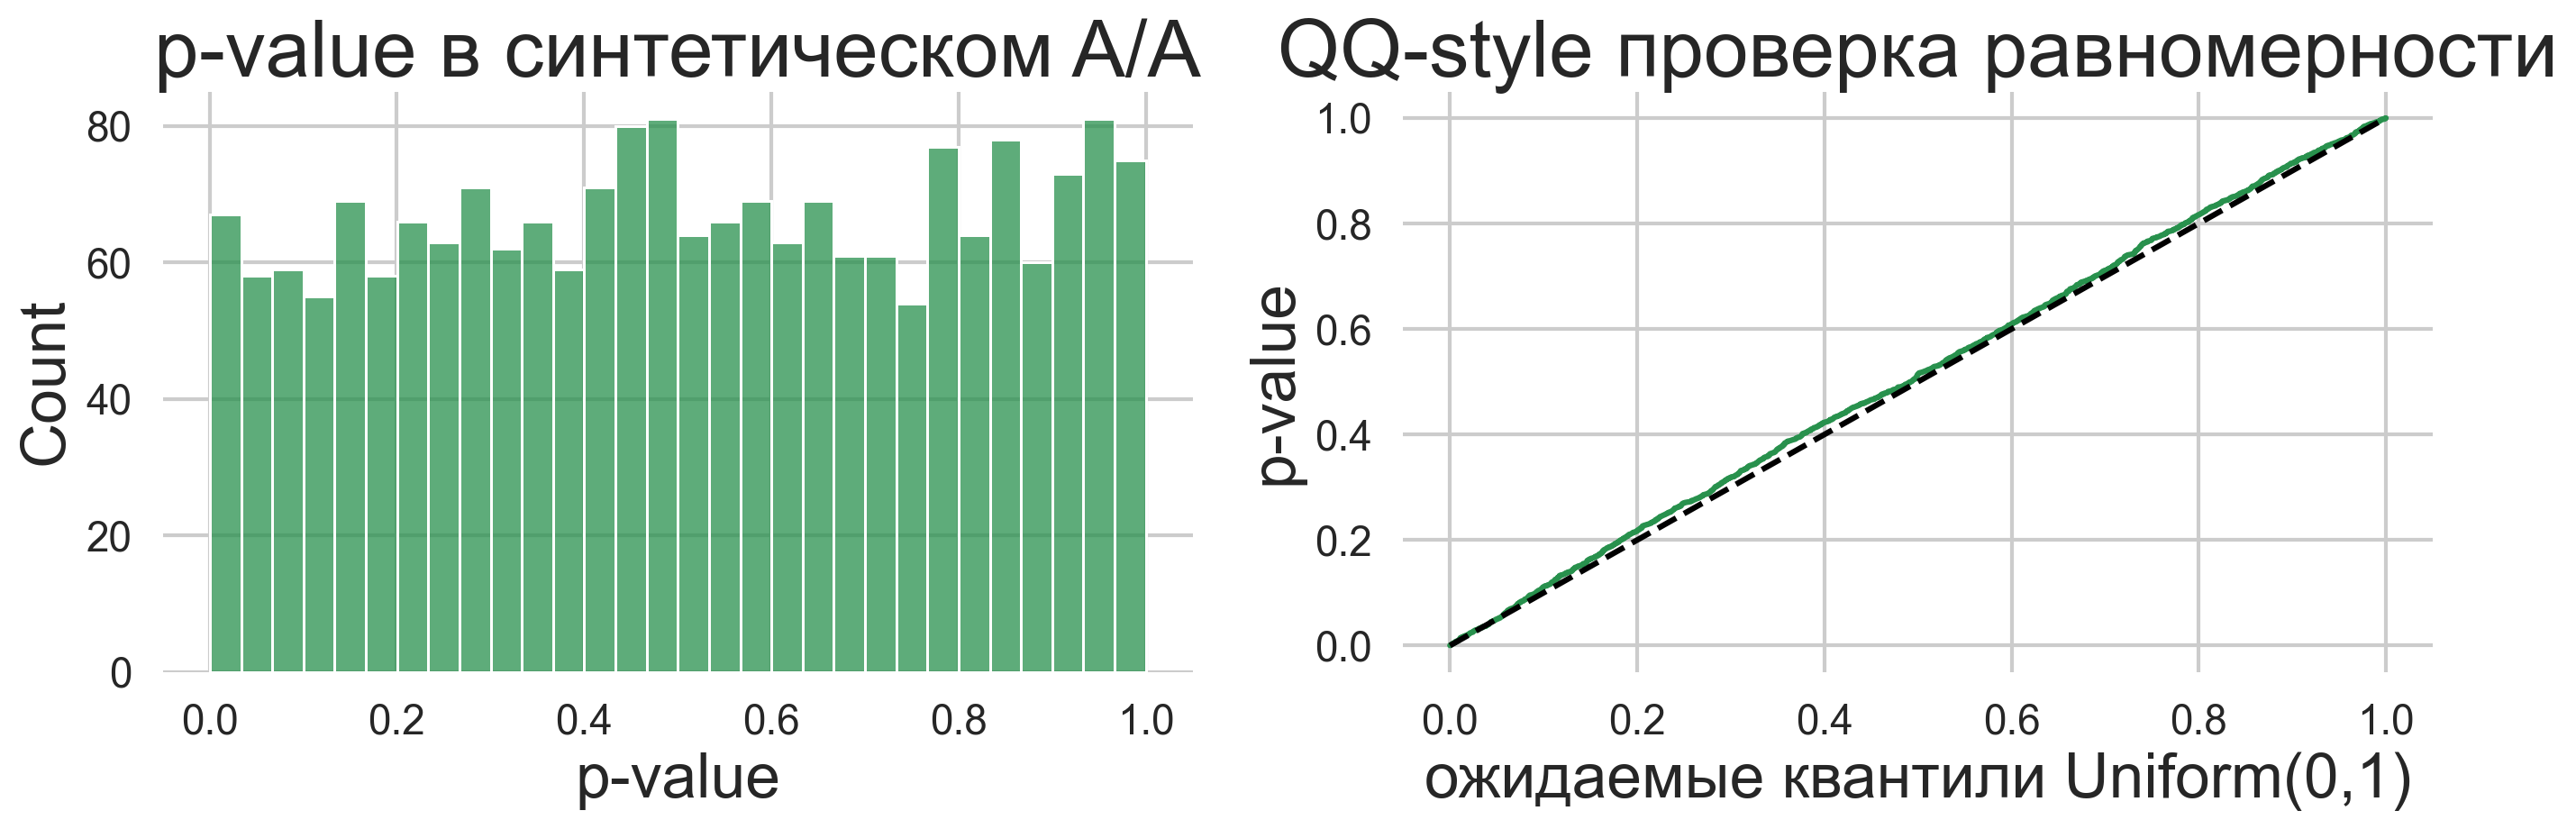

## 6. Непараметрические критерии: KS и Mann-Whitney

### Двухвыборочный критерий Колмогорова-Смирнова

Проверяет, похожи ли распределения двух выборок. Статистика -- максимальное расстояние между эмпирическими функциями распределения теста и контроля.

### Mann-Whitney U-test

Ранговый непараметрический критерий. Проверяет гипотезу о стахостическом доминировании:

$$
H_0: P(X_T > X_C) = P(X_T < X_C) = 0.5
$$

То есть случайно выбранный пользователь из теста должен обгонять случайно выбранного пользователя из контроля с вероятностью около 1/2, если эффекта нет.


### От себя: Permutation test

Проверяет нипотезу об одинаковом распределении:

$$
H_0: F_{control} = F_{test}
$$

Идея: Если выборки взяты из одного распределения, то мы имеем право переставлять наблюдения мажду выборками и ничего не поменяется. Распределение статистики формируется всеми возможными перестановками и подсчетом статистики на них.


### Сравнение мощности методов

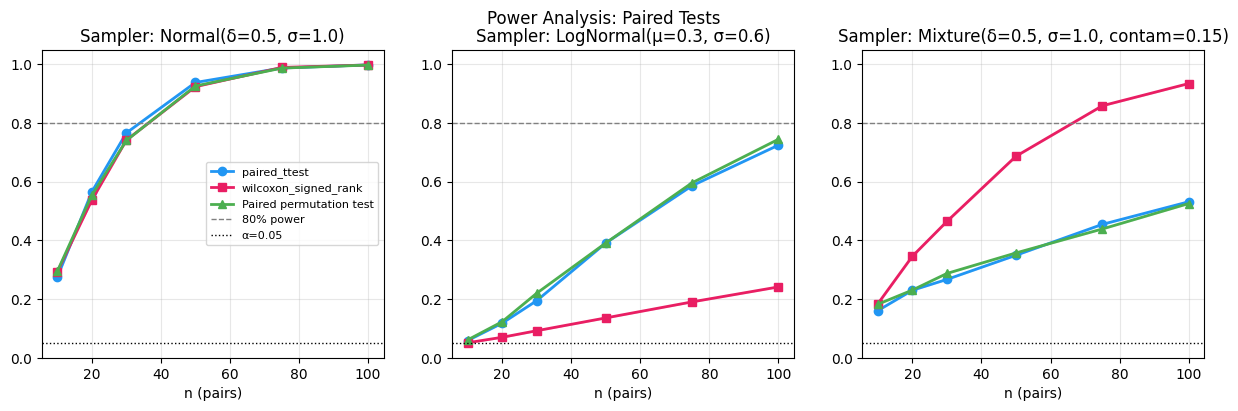

## 7. Ratio-метрики

В продуктовых A/B-тестах очень часто встречаются метрики отношения:

$$
R = \frac{\sum X_i}{\sum Y_i}
$$

Примеры:

- конверсия = число целевых действий / число пользователей или сессий;
- средний чек = выручка / число заказов;
- GMV на поездку;
- успешные поездки / все заказы;
- выручка / активные пользователи.

> Отношение случайных величин не анализируется обычным ттестом, ведь часто мы хотим именно общую долю, например конверсии(5/100, 4/5, срежнее будет огромное, а общая доля оч маленькая). Нужны специальные методы: дельта-метод, линеаризация, бакетизация, bootstrap.


## 8. Дельта-метод для ratio-метрик

Дельта-метод аппроксимирует дисперсию сложной функции через разложение Тейлора первого порядка.

Есть случайная величина $ \Delta =  \dfrac{ \bar X_t}{ \bar Y_t}  - \dfrac{ \bar X_c}{ \bar Y_c} $, при ВЕРНОСТИ $H_0$ хотим понять как она РАСПРЕДЕЛЕНА, какая у нее ДИСПЕРСИЯ (МАТОЖИДАНИЕ по условию 0).

---

**Одномерный дельта-метод**:

Если последовательность случайных величин $X_n$ сходится по распределению к $\sqrt{n}[X_n - \mu]  \xrightarrow{\text{d}} \mathcal{N}(0, \sigma^2)$, где $\mu$ и $\sigma$ -- конечные константы, то для любой $g(t)$ -- непрерывной и дифференцируемой трансформации, такой что $g'(\mu) \neq 0$, имеем  

$$\sqrt{n}[g(X_n) - g(\mu)]  \xrightarrow{\text{d}} \mathcal{N}(0, \sigma^2\cdot g'(\mu)^2)$$


---

Доказательство:

Мы используем разложение функции $g(t)$ в ряд Тейлора в окрестности точки $\mu$:

$$
g(X_n) \approx g(\mu) + g'(\mu) (X_n-\mu)
$$ 

Тогда математическое ожидание и дисперсия будут равны

$E[g(X_n)] \approx g(\mu) + g'(\mu) E[X_n-\mu] = g(\mu)$ 

и 

$\text{Var}[g(X_n)] \approx 0 + g'(\mu)^2 (\text{Var}X_n - 0) = \sigma^2 \cdot g'(\mu)^2$.


Для отношения $R = \bar X / \bar Y$ градиент:

$$
\nabla g = \left(\frac{1}{\mu_Y}, -\frac{\mu_X}{\mu_Y^2}\right)
$$

Тогда:

$$
Var(R) \approx \frac{1}{n}\left(
\frac{Var(X)}{\mu_Y^2} +
\frac{\mu_X^2 Var(Y)}{\mu_Y^4} -
2\frac{\mu_X Cov(X,Y)}{\mu_Y^3}
\right)
$$

Для разницы двух независимых ratio-метрик дисперсии складываются.

> Дельта-метод позволяет быстро считать p-value и доверительные интервалы для сложных бизнес-метрик без дорогого bootstrap.

Этот способ хорошо обобщается на многомерный случай: 
 
$$
\mathcal{D}[g(X_n, Y_n, ...)] \approx \nabla g(\mu_{X_1}, \mu_{X_2}, ...)^T  \mathbf{\Sigma} \nabla g(\mu_{X_1}, \mu_{X_2}, ...), 
$$  
 
где $\mathbf{\Sigma}$ - матрица ковариации 

$\nabla$ - градиент.




## 9. Линеаризация ratio-метрики

Линеаризация переводит отношение к пользовательской метрике. Это нужно, чтобы дальше применять обычные методы для средних и методы уменьшения дисперсии.

Один из полезных вариантов:

$L(u) = X(u) - R^c Y(u)$

где 

$R^c$ - значие метрики отношения в контроле. 

$\text{sgn} \Delta(R^t - R^c) = \text{sgn}  \Delta(\bar L^t - \bar L^c)$, то есть есть сонаправленность. 


$\bar L = \bar X - R^c \bar Y = \bar Y(\dfrac{\bar X}{\bar Y} - R^c)$

$\bar L^t = \bar Y^t(R^t - R^c), \, \bar L^c = 0$

$$\bar L^t - \bar L^c  = \bar Y^t(R^t - R^c)$$

Если тестовая группа имеет тот же ratio, среднее $L_i$ в тесте будет близко к среднему в контроле. Если ratio изменился, разница средних линеаризованной метрики поймает это изменение.

2.  тип

Разложение в ряд Тейлора для непрерывной трансформации $g(X, Y) = \frac{X}{Y}$ в окрестности матожидания: 

$\dfrac{X}{Y} \approx \dfrac{\mu_X}{\mu_Y} + \dfrac{1}{\mu_Y}(X - \mu_X) -\dfrac{\mu_X}{\mu_Y^2}(Y-\mu_Y) = \dfrac{\mu_X}{\mu_Y} + \dfrac{1}{\mu_Y}X - \dfrac{\mu_X}{\mu_Y^2}Y$

$L(u) = \dfrac{\bar X}{\bar Y} + \dfrac{1}{\bar Y} X(u) - \dfrac{\bar X}{\bar Y^2} Y(u) = \boxed{R +  \dfrac{1}{\bar Y}(X(u) - R Y(u))}$.


$$\frac{\bar X}{\bar Y} \approx \frac{1}{n}\sum_{u} \left(\dfrac{\mu_X}{\mu_Y} + \dfrac{1}{\mu_Y}X(u) - \dfrac{\mu_X}{\mu_Y^2} Y(u) \right) \stackrel{d}{\rightarrow} \bar L$$

> Тут, если взять $\bar{L}$, то в матоже будет глобальное отношение, из за чего способ прикольнее, также спокойно находится дисперсия


## 10. Бакетизация и bootstrap

### Бакетизация

Пользователей случайно делят на бакеты, внутри каждого бакета считают сложную метрику, а затем сравнивают бакетные значения. Это превращает сложную метрику в набор наблюдений.

Минус: бакетизация теряет информацию и может снижать мощность.

### Bootstrap

Много раз сэмплируем пользователей с возвращением, каждый раз считаем метрику и строим распределение оценки. Это универсальная отмычка для почти любой метрики.

Минус: bootstrap дорогой. В промышленных задачах с тысячами экспериментов, метрик и срезов он может стать слишком тяжелым.

### Puasson bootstrap

Из за того, что на больших данных может быть тяжело проводить бутстрап, можно использовать распределение пуассона, с E = 1 и каждому клиенту назначать вес как наблюдение, взятое из распределения. Таким образом используется меньше ресурсов.

> Также, будет работать permutation test(который было выше(его надо просто адекватно задизайнить)), поэтому он мета

> Мини-итог по ratio-метрикам: bootstrap универсален, но дорогой; бакетизация проста, но теряет информацию; дельта-метод быстрый и мощный; линеаризация удобна, когда нужен переход к поюзерной метрике и дальнейшее применение методов вроде CUPED.





### Сравнение методов работы с ratio метриками по мощности
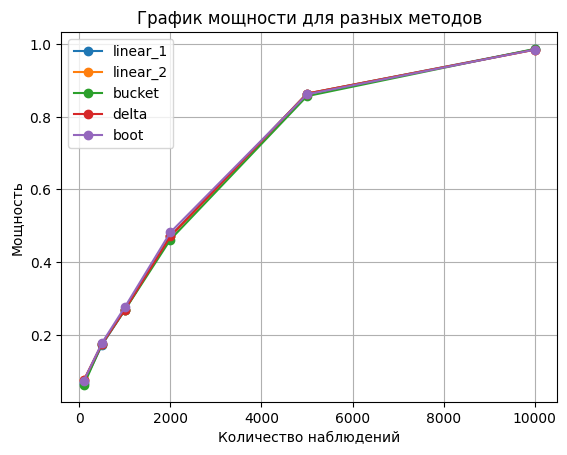



## 11. Доверительные интервалы и серые метрики

Точечная оценка говорит: "эффект равен 1.2%". Но без интервала непонятно, насколько оценка надежна.

Доверительный интервал показывает диапазон правдоподобных значений эффекта. Это особенно важно для серых метрик:

- метрика не прокрасилась, но интервал широкий и включает большой минус -- риск есть;
- метрика не прокрасилась, но интервал узкий около нуля -- сильного вреда, вероятно, нет;
- метрика прокрасилась, но эффект маленький -- статистическая значимость не обязательно означает бизнес-значимость.

> Менеджеры любят игнорировать серые метрики, но именно там часто скрыта информация о рисках.


## 12. Uplift

Бизнес часто хочет относительный эффект:

$$
uplift = \frac{metric_T - metric_C}{metric_C}
$$

Но uplift -- это отношение случайных величин. Даже если исходная метрика простая, uplift требует аккуратной оценки дисперсии.

Для value-метрик и ratio-метрик дельта-метод позволяет вывести дисперсию uplift-а и построить доверительный интервал.

Вывод: нельзя просто посчитать `+3%` и забыть. Нужно понимать доверительный интервал uplift-а: например, `+3% [-1%, +7%]` и `+3% [+2.5%, +3.5%]` -- это совершенно разные ситуации для принятия решения.


## 13. Персентильные доверительные интервалы

Персентили полезны, когда среднее плохо описывает бизнес-ситуацию:

- время ожидания;
- latency;
- стоимость/чек с тяжелым хвостом;
- время доставки;
- любые метрики, где важен не средний пользователь, а хвост распределения.

Например, бизнесу может быть важен не средний latency, а 95-й перцентиль: "95% запросов должны быть быстрее X".

Для одного распределения можно строить доверительный интервал для истинного перцентиля через порядковые статистики. Идея:

1. сортируем выборку;
2. настоящий $p$-перцентиль должен лежать между некоторыми порядковыми статистиками;
3. номера этих порядковых статистик подбираются через биномиальное распределение.

На практике для A/B чаще сложнее: нас интересует не один перцентиль, а разница перцентилей test-control. Для такой задачи проще и универсальнее использовать bootstrap:

> Персентили очень чувствительны к выбросам в хвостах. Поэтому percentile CI и outliers -- связанные темы.




> Мини-итог: перцентильные метрики нужны для хвостов распределения, но они нестабильнее средних и сильнее зависят от выбросов. Для разницы перцентилей test-control самый понятный практический вариант -- bootstrap.



## 14. Аутлайеры

Аутлайеры в A/B-тестах -- это не просто "выбросы", которые надо дропнуть. Для статистики это одна из самых неприятных историй, потому что:

- T-test очень чувствителен к сильным выбросам;
- выбросы раздувают дисперсию, а значит увеличивают MDE и уменьшают мощность;
- несколько огромных пользователей/заказов могут визуально и статистически двигать среднее;
- если удалять выбросы по-разному в тесте и контроле, можно сломать валидность критерия.

> С выбросами надо работать аккуратно и одинаково для обеих групп. Самая плохая идея -- подобрать порог уже после того, как увидели результат эксперимента.

Что обычно можно делать:

1. **Проверить техническую природу выбросов**  
   Например, дубли событий, баг логирования, отрицательная цена, нереально большой чек, кривой timestamp. Такие ошибки можно и нужно чистить как технический мусор.

2. **Заранее зафиксировать правило обработки**  
   Например: winsorize по 99.5 перцентилю исторического распределения или cap по бизнес-порогу.

3. **Использовать общий порог, а не отдельный порог для test/control**  
   Если в контроле удалить всё выше 99-го перцентиля контроля, а в тесте всё выше 99-го перцентиля теста, мы применяем разные трансформации к группам. Это может искусственно приблизить группы и исказить p-value.

4. **Лучше брать порог из исторических данных или из объединенного pre-period**  
   То есть порог должен быть независим от экспериментального эффекта.

5. **Иногда выбрать более робастный критерий/метрику**  
   Mann-Whitney более робастен к выбросам, чем T-test, но он проверяет другую гипотезу. Персентильные метрики тоже могут быть полезны, но с ними сложнее строить доверительные интервалы.

Правильно:

> Выбросы можно чистить, если это заранее описанная часть дизайна эксперимента. Нельзя заниматься p-value hackingом. (кста в даношке 24 года была задача, в которой надо было провести аб тест, и в котором надо было дропать выбросы на глаз в тестовой группе)

> Мини-итог: выбросы чаще всего уменьшают чувствительность теста через рост дисперсии. Работать с ними надо до анализа результата: технические ошибки удаляем, бизнес-экстремумы дропаем по заранее выбранному общему правилу. Отдельные пороги для test/control -- подозрительная история.

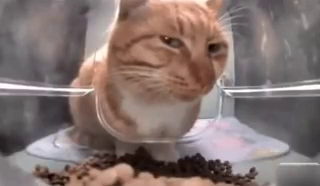


## 15. CUPED

**CUPED** -- Controlled-experiment Using Pre-Experiment Data. Это метод повышения чувствительности A/B-теста за счет информации о пользователе до эксперимента.

Идея: если пользователь был активным/дорогим/частым до эксперимента, то он с высокой вероятностью будет активным и во время эксперимента. Значит pre-period метрика объясняет часть дисперсии post-period метрики. Если учесть это, мы сможем снизить дисперсию у групп, из за чего тест станет более мощным

Пусть:
- $Y_i$ -- метрика пользователя в экспериментальном периоде;
- $X_i$ -- та же или похожая метрика pre-period;
- $Z_i$ -- CUPED-трансформированная метрика.

Строим:

$$
Z_i = Y_i - \theta X_i + \theta E[X]
$$

Константу $\theta E[X]$ добавляют, чтобы матожидание метрики не менялось

Дисперсия:

$$
Var(Y - \theta X) = Var(Y) + \theta^2 Var(X) - 2\theta Cov(X, Y)
$$

Минимум достигается при:

$$
\theta = \frac{Cov(X, Y)}{Var(X)}
$$

Тогда:

$$
Var(\bar Z) = Var(\bar Y)(1 - r^2)
$$

где $r$ -- корреляция между pre-period и post-period метрикой.

> CUPED работает тем лучше, чем сильнее pre-period метрика коррелирует с post-period метрикой.


### Как применять CUPED на практике

1. Собираем данные по пользователям за pre-period: $X_i$.
2. Собираем метрику за экспериментальный период: $Y_i$.
3. Оцениваем $\theta$ по объединенным данным test+control:

$$
\hat\theta = \frac{\widehat{Cov}(X, Y)}{\widehat{Var}(X)}
$$

4. Строим новую метрику:

$$
Z_i = Y_i - \hat\theta X_i
$$

Константу $\theta E[X]$ можно не добавлять при сравнении test-control, потому что она сокращается в разнице средних.

5. Делаем обычный тест уже по $Z_i$.

- $\theta$ нельзя подбирать отдельно в тесте и контроле;
- CUPED требует поюзерную метрику, поэтому для ratio-метрик часто сначала используют линеаризацию;
- новичков и редких пользователей надо обработать отдельно, потому что у них может не быть pre-period.


### Что делать с новичками и редкими пользователями

Проблема CUPED: нужен pre-period. Но в реальном продукте есть:

- новые пользователи, которых не было в истории;
- редкие пользователи, у которых pre-period почти пустой;
- пользователи, у которых pre-period не репрезентативен.

Варианты:

- оставить $X_i = 0$ или специальное значение, если это осмысленно;
- заменить отсутствующий pre-period на среднее;
- добавить отдельный флаг `is_new_user`;
- считать CUPED только для пользователей с историей, а новичков анализировать отдельно;
- использовать более широкую ковариату: активность, факт появления, сегмент, гео, тариф.

Главное: правило обработки новичков должно быть задано до анализа результата. Иначе CUPED превращается в еще один способ заниматься p-value hackingом.

> Мини-итог: CUPED -- трансформация метрики, которая уменьшает дисперсию. После CUPED можно делать обычный тест, но уже по $Z_i$. Лучший случай для CUPED -- стабильная пользовательская метрика с высокой корреляцией между pre-period и experiment-period.


## 16. Стратификация

Идея: пользователи неоднородны. Например, Москва, Санкт-Петербург и маленький регион могут иметь разные средние чеки и частоту использования сервиса. Если случайный сплит случайно дал в тест больше "дорогих" пользователей, дисперсия оценки растет.

Стратификация:

1. заранее делим популяцию на непересекающиеся страты;
2. знаем доли страт в ГС;
3. набираем тест и контроль так, чтобы доли страт совпадали с популяцией;
4. считаем стратифицированное среднее и стратифицированную дисперсию.

Примеры страт: гео, новичковость, основной тариф, класс машины для водителей, любые признаки, сильно определяющие поведение.

> Здесь можно брать обычное среднее, но не обычную дисперсию:

$$
\mathrm{Var}(\overline{X}_{\text{strat}})
= \sum_{k=1}^{K} w_k\, \frac{n_k}{n} \frac{\sigma_k^2}{n_k} = \frac{1}{n}\sum_{k=1}^{K} w_k\,\sigma_k^2
$$

где $w_k$ -- доля страты в ГС


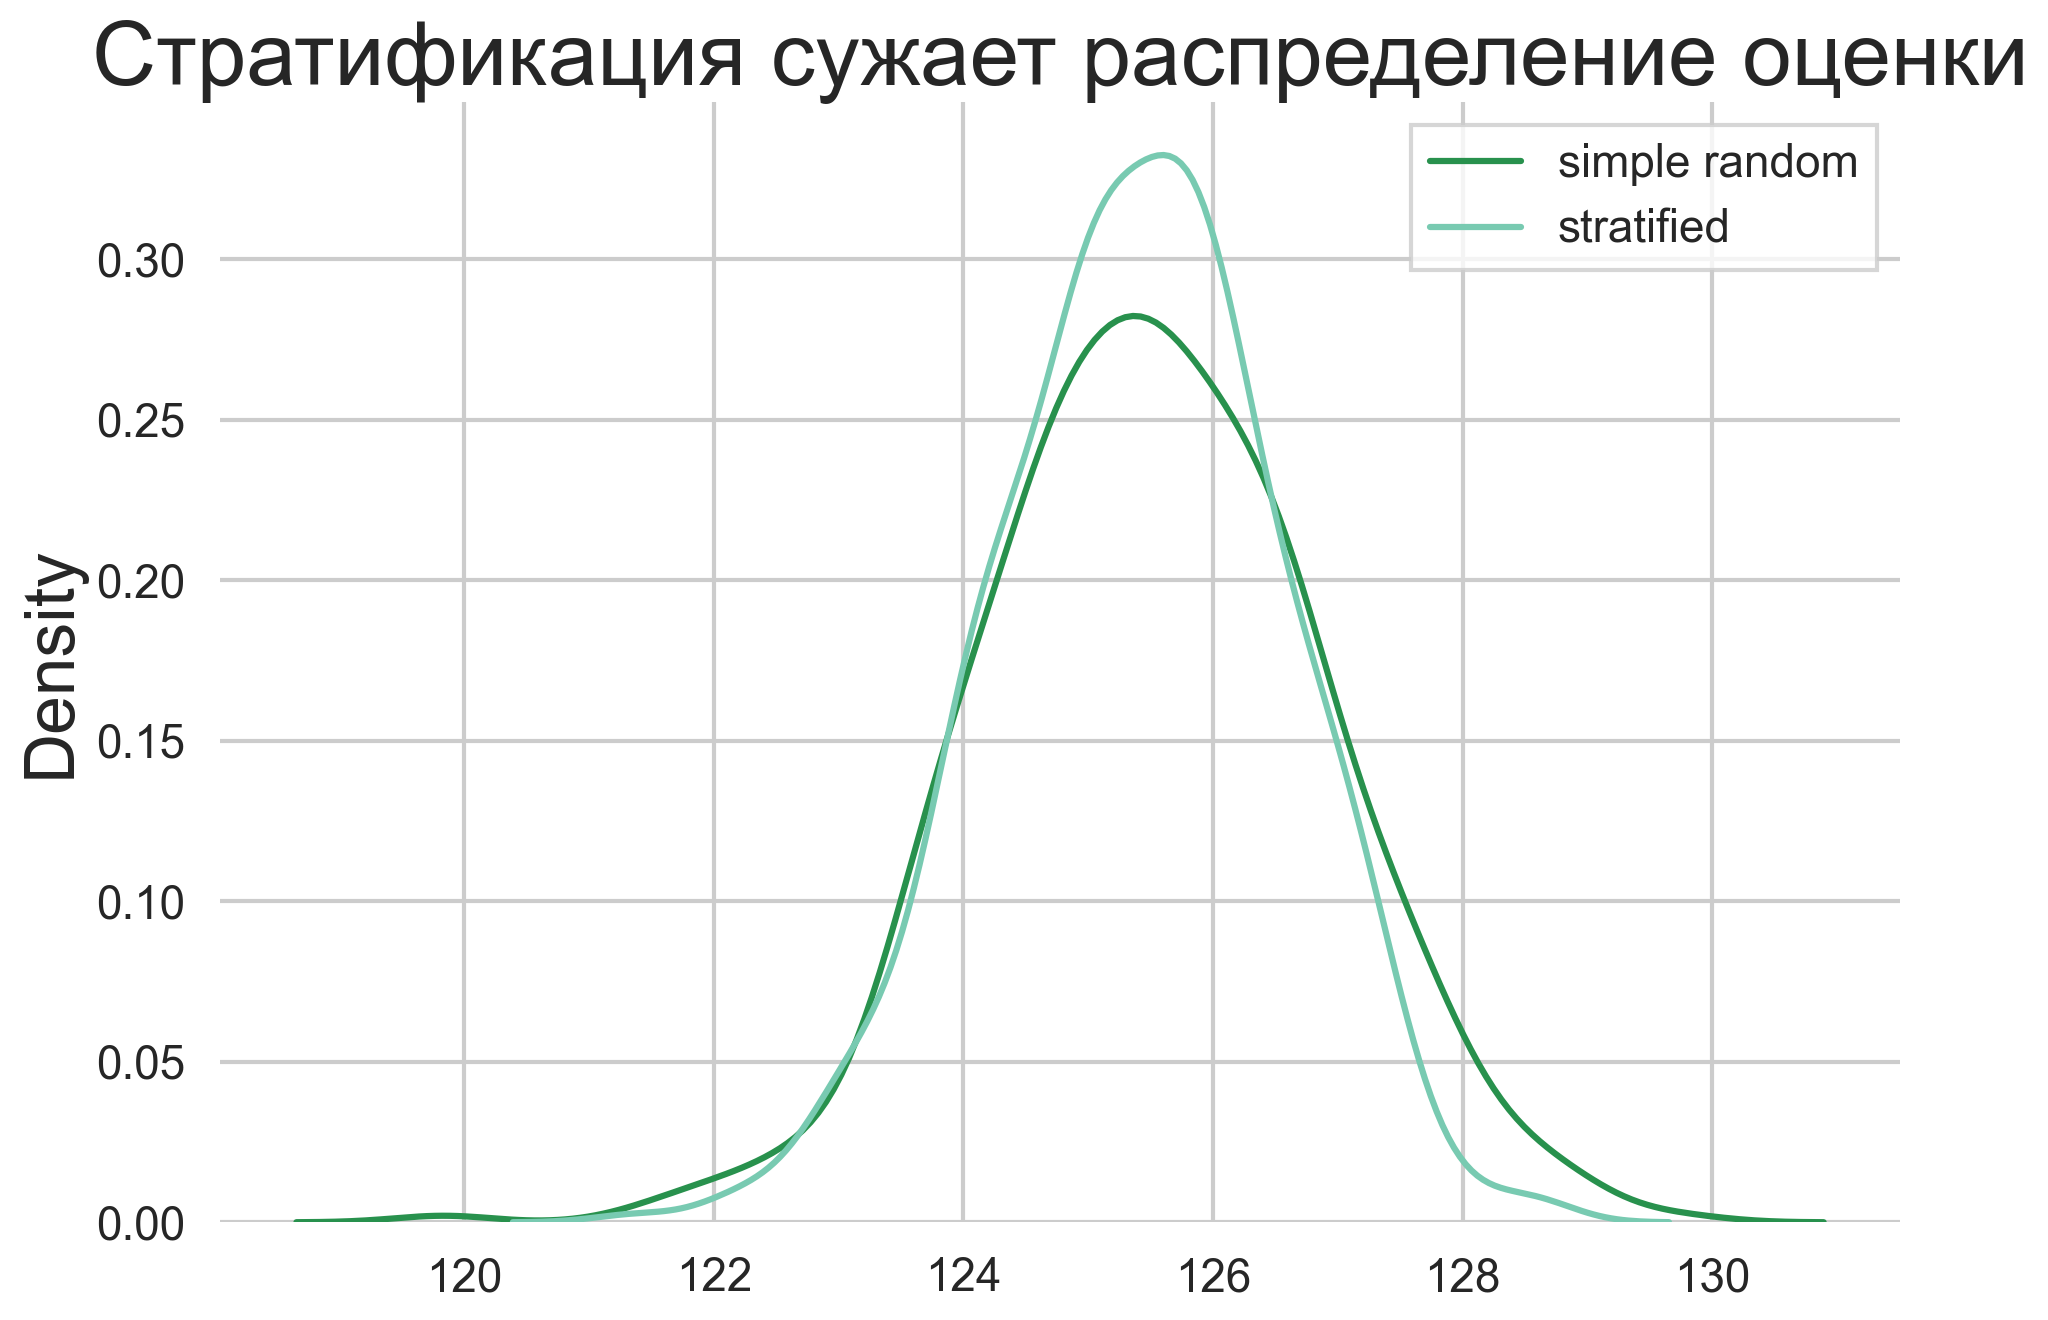

> Мини-итог: стратификация особенно полезна, когда страты сильно отличаются по средним. Если страты почти одинаковые, большого выигрыша не будет. Но если страты объясняют поведение, дисперсия уменьшается и мощность растет.





## 17. Постстратификация

Постстратификация нужна, когда на этапе сплита нет технической возможности набрать тест и контроль по долям страт.

Схема:

1. сплит делается обычным случайным способом;
2. после эксперимента мы знаем страты пользователей;
3. считаем стратифицированное среднее с популяционными весами;
4. дисперсию считаем специальной формулой, потому что число пользователей в стратах случайно.

Стратифицированное среднее:

$$
\bar X_{strat} = \sum_k w_k \bar X_k
$$

Дисперсия асимптотически сходится к тому же самому

$$
\mathrm{Var}(\overline{X}_{\text{strat}})
= \sum_{k=1}^{K} w_k\, \frac{n_k}{n} \frac{\sigma_k^2}{n_k} = \frac{1}{n}\sum_{k=1}^{K} w_k\,\sigma_k^2
$$

> Постстратификация позволяет получить часть пользы стратификации без сложной сплитовалки. Но важно не только пересчитать среднее, а и правильно пересчитать дисперсию, иначе критерий будет некорректен.



## 18. Множественное тестирование

В реальном A/B-тесте редко есть одна метрика и одна гипотеза. Обычно есть целевые метрики, guardrail-метрики, технические метрики, срезы по гео/платформе/тарифу/новичковости и несколько тестовых групп.

Если проверять $m$ независимых гипотез с уровнем $\alpha$, вероятность хотя бы одного ложного срабатывания:

$$
P(\text{at least one false positive}) = 1 - (1 - \alpha)^m
$$

При $\alpha=5\%$ и десятках/сотнях гипотез хотя бы один случайный прокрас почти гарантирован.

(Тута можно вспомнить мертвого лосося)




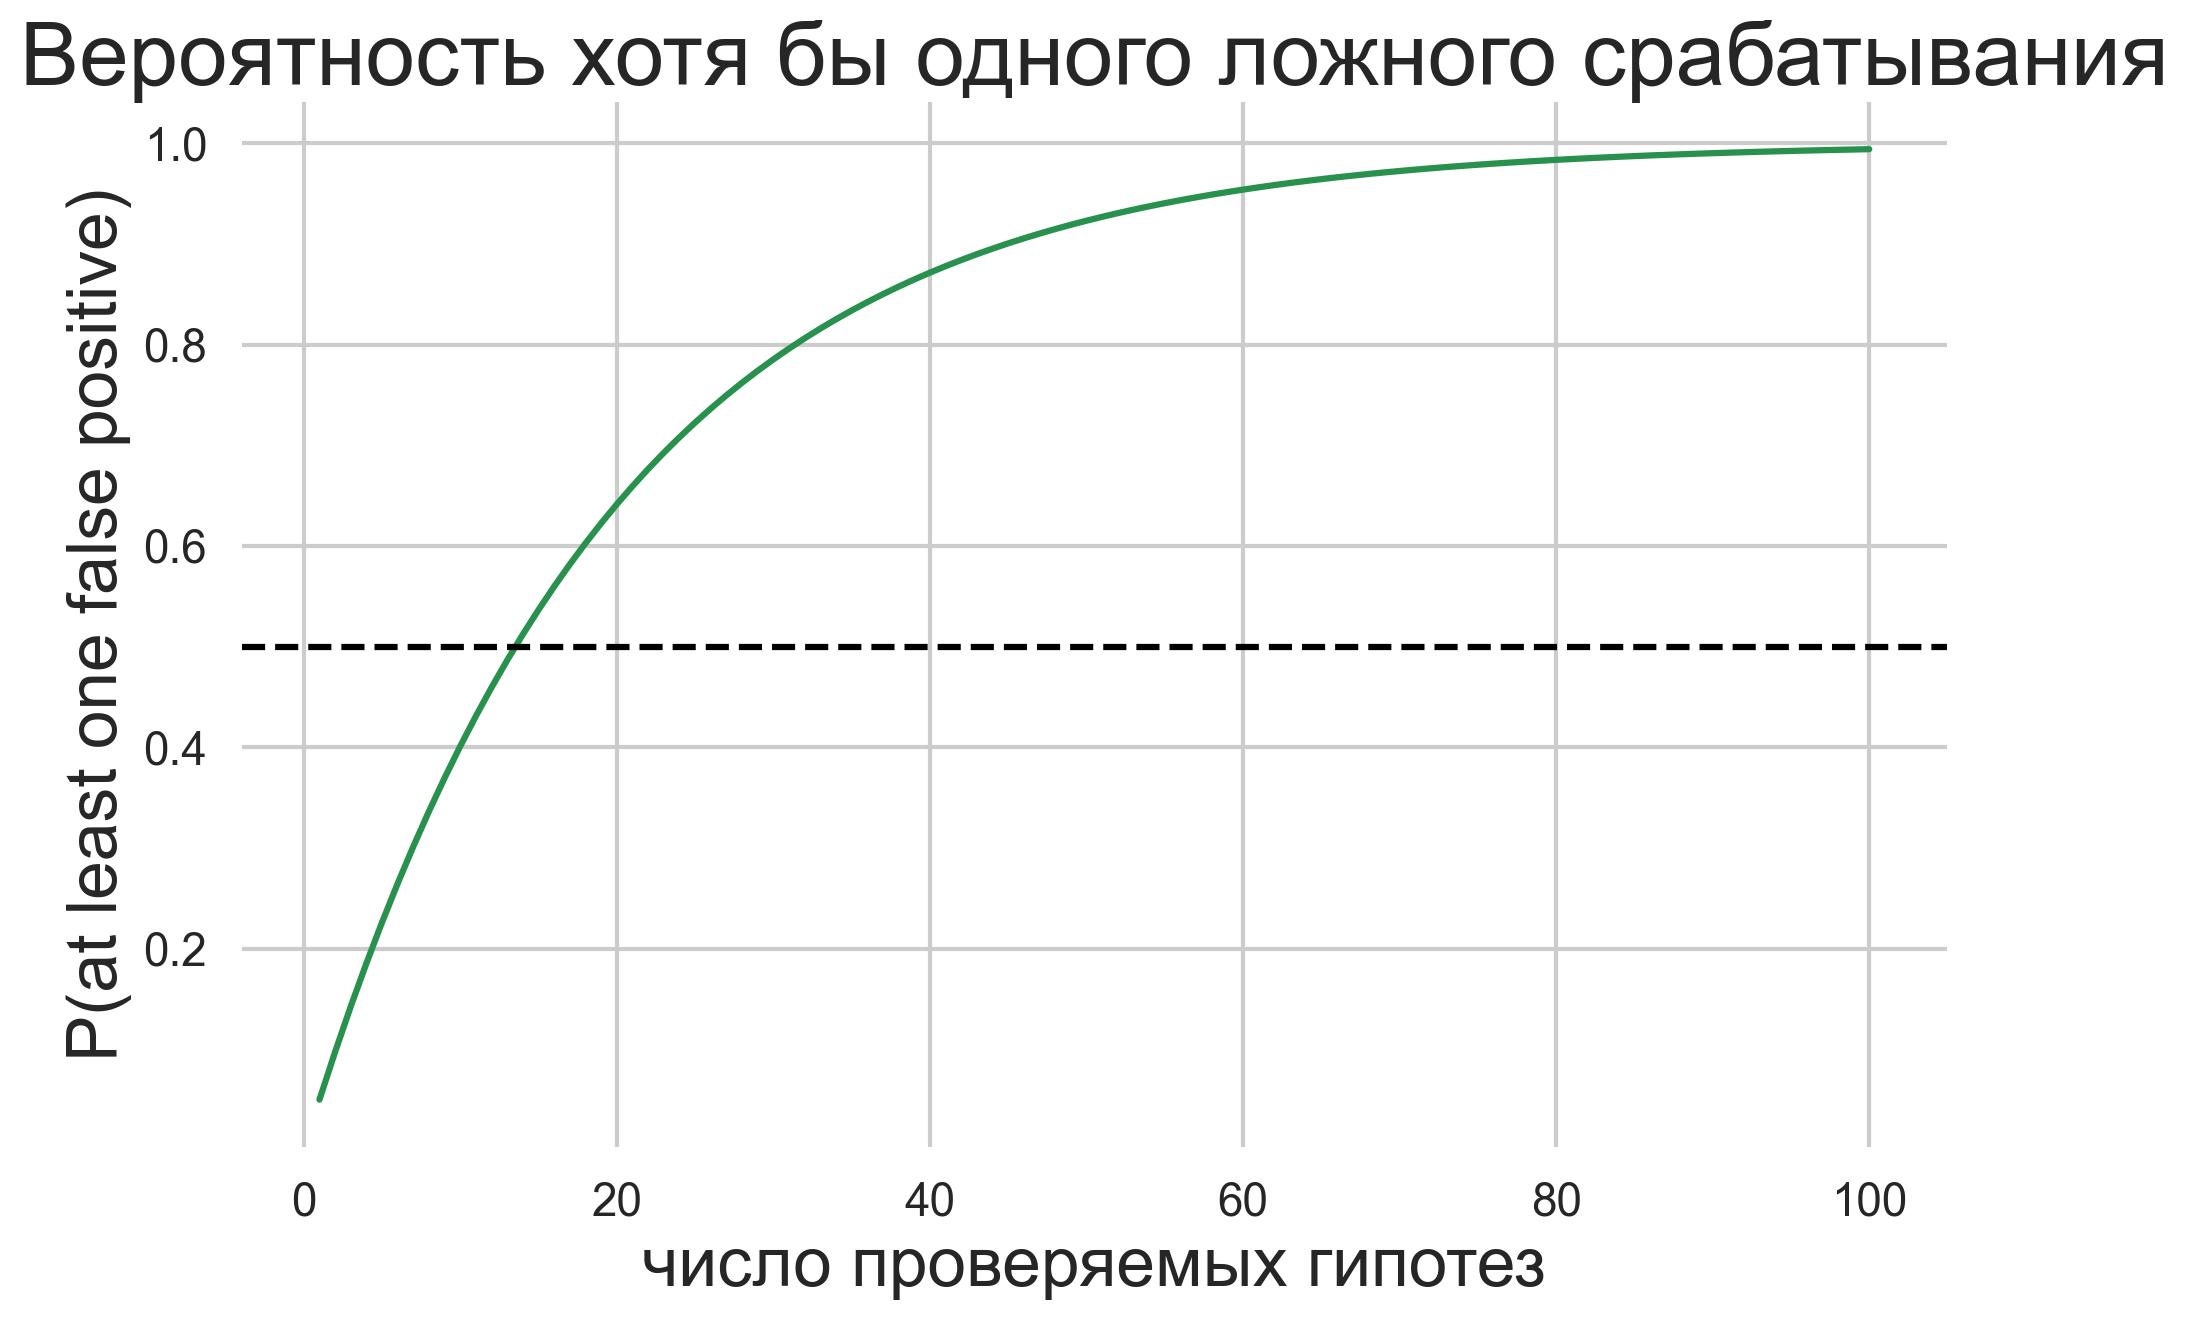

## 19. Поправки: Bonferroni, Sidak, Holm, Benjamini-Hochberg

### FWER

FWER контролирует вероятность хотя бы одной ошибки первого рода во всем семействе гипотез.

- **Bonferroni**: сравниваем каждое p-value с $\alpha / m$. Очень консервативно.
- **Sidak**: порог $1 - (1 - \alpha)^{1/m}$. Немного менее жестко при независимости.
- **Holm-Bonferroni**: сортируем p-value и идем пошагово. Обычно мощнее обычного Bonferroni.

### FDR

FDR контролирует долю ложных открытий среди всех открытий.

- **Benjamini-Hochberg**: сортируем p-value и сравниваем с растущими порогами $\alpha \cdot i / m$.

Вывод: FWER полезен, когда ложное срабатывание очень дорого. В продуктовой аналитике часто разумнее FDR, потому что он меньше убивает мощность.


## 20. Байесовский A/B-тест

До этого весь курс был про классический частотный подход:

- есть нулевая гипотеза $H_0$;
- считаем статистику критерия;
- получаем p-value;
- если `p-value < alpha`, отвергаем $H_0$.

Интерпретация p-value неудобная: это вероятность получить такие или более экстремальные данные при условии, что эффекта нет. Это не вероятность того, что тест лучше контроля.

Байесовский подход формулирует вопрос иначе:

> Какое распределение у параметра после того, как мы увидели данные?

То есть мы задаем распределение для неизвестного параметра метрики, обновляем его данными и получаем posterior.

Формула:

$$
Posterior = \frac{Likelihood \cdot Prior}{Evidence}
$$

где:

- **Prior** -- априорное распределение, что мы думали о параметре до эксперимента;
- **Likelihood** -- вероятность увидеть текущие данные при заданном параметре;
- **Posterior** -- апостериорное распределение, что мы думаем о параметре после данных;
- **Evidence** -- нормировочная константа, чтобы posterior был распределением.

Для A/B-теста это дает более прямой ответ:

$$
P(\theta_B > \theta_A \mid data)
$$

То есть можно сказать: "вероятность, что B лучше A, равна ...".


### Beta-Binomial модель для конверсии

Для конверсии естественная модель:

- у каждого пользователя Bernoulli распределение: 1/0;
- число успехов в группе имеет биномиальное распределение;
- параметр $\theta$ -- истинная вероятность конверсии.

Если prior:
$$
\theta \sim Beta(a, b)
$$

и в данных:
- $x$ успехов;
- $n - x$ неуспехов,

то posterior снова Beta:
$$
\theta \mid x, n \sim Beta(a + x, b + n - x)
$$

Самые частые prior для конверсии:
- `Beta(1, 1)` -- равномерный prior, как будто ничего не знаем;
- `Beta(0.5, 0.5)` -- Jeffreys prior, более осторожный на краях;
- информативный prior из истории, например если историческая конверсия около 5%, можно взять параметры, соответствующие этому среднему.

Если данных много, prior влияет слабо. Если данных мало, prior может сильно двигать вывод, поэтому надо проверять sensitivity к prior.


### Как принимать решение

В байесовском тесте нет p-value. Нужно заранее выбрать decision rule.

Примеры правил:

1. **Probability of superiority**

   Внедряем, если:

   $$
   P(\theta_B > \theta_A) > 0.95
   $$

2. **Probability of practical improvement**

   Внедряем, если B не просто лучше, а лучше на бизнес-значимый порог:

   $$
   P(\theta_B - \theta_A > MDE) > 0.9
   $$

3. **Expected loss**

   Считаем ожидаемый проигрыш от выбора B, если B окажется хуже A. Это ближе к бизнес-решению, потому что учитывает размер возможного вреда.

Главная ошибка: получить `P(B > A) = ...` и не понимать, что с этим делать. Поэтому decision rule фиксируется до анализа, как $alpha$ в частотном подходе.


### Нормальный prior для средних

Если метрика примерно нормальная, можно моделировать среднее.

Пусть:
$$
X_i \sim N(\theta, \sigma^2)
$$

и prior на среднее:
$$
\theta \sim N(\mu_0, \tau_0^2)
$$

Тогда posterior тоже нормальный:
$$
\frac{1}{\tau_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2}
$$

$$
\mu_n = \tau_n^2 \left(\frac{\mu_0}{\tau_0^2} + \frac{n\bar{x}}{\sigma^2}\right)
$$

Если prior очень широкий, например $N(0, 1000^2)$, он почти не влияет, и результат близок к классическому анализу.


### Плюсы и минусы байесовского подхода

Плюсы:

- ответ интерпретируется напрямую: `P(B > A)`;
- можно получать байесовские CI для эффекта/upliftа;
- удобно обновлять вывод по мере поступления данных;
- меньше проблем с ~~кончеными~~ людьми, которые не умеют ждать, из за чего смотрят ранее на предварительные результаты теста(и могут остановить тоже заранее, когда нашли статзначимую разницу), потому что posterior просто обновляет знание;
- хорошо работает при малых данных, если есть адекватный prior.

Минусы:

- нужно выбрать prior(как?);
- при малых данных prior может сильно влиять на вывод;
- необходимо заранее сделать decision rule;
- решения принимаются по вероятности превосходства/expected loss (кста не всегда минус, просто не привычно);
- для сложных метрик модель может быть нетривиальной.

## 21. Итоговый чеклист проведения A/B-теста

### До запуска

1. Зафиксировать продуктовую гипотезу.
2. Выбрать главную метрику.
3. Выбрать guardrail-метрики.
4. Определить $\alpha$, мощность, MDE.
5. Посчитать размер выборки.
6. Заранее определить срезы.
7. Решить, нужна ли стратификация.
8. Проверить, что сплит технически корректен(например, стратификация может быть технически тяжелым действием, из за того, что сильно поменялось распределение по стратам).

### Во время анализа

1. Проверить баланс групп и корректность данных.
2. Понять тип метрики: value или ratio.
3. Выбрать критерий под гипотезу.
4. Провести А/А тест.
5. Посчитать эффект, p-value и доверительный интервал.
6. Смотреть не только прокрасы, но и серые метрики, их CI.
7. Проверить выбросы по заранее заданному правилу.
8. Если есть хорошая pre-period ковариата, применить CUPED.
9. Учесть множественное тестирование.
10. Если используем Байесовский A/B, заранее зафиксировать prior и decision rule.

### После анализа

1. Сравнить статистическую и бизнес-значимость.
2. Проверить guardrail-метрики.
3. Не делать cherry-picking по срезам(выборочное выводы по срезам).
4. Зафиксировать решение и риски.


## Источники

### Основной источник

- Видео интенсив ШАД по A/B-тестам [тык](https://shad.yandex.ru/abweek)
- Также, сказания Глеба Пильноватых


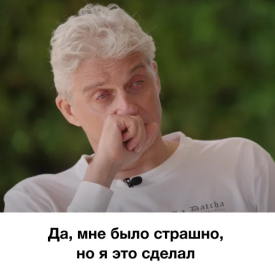

(я устал, босс...)